In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm
import warnings
# from google.colab import files
warnings.filterwarnings('ignore')

In [3]:
# Strategy Parameters
TBILL          = 'TB3M_ROR'
MARKET         = 'Equity_US_ROR'
LOOKBACK       = 120
FULL_MVO_START = '2000-01-01'

# Strategy Return Columns
DM_SERIES  = ['Dual_Equity','Dual_Credit','Dual_REIT','Dual_Stress']

In [4]:
# upload = files.upload()

In [5]:
def load_data(path_returns='returns.csv', path_regime='regime_signal.csv'):
    # Load returns data
    returns = pd.read_csv(path_returns, parse_dates=['Date'])
    returns = returns.sort_values('Date').ffill().bfill()

    # Load regime signal and align to first of month
    regime = pd.read_csv(path_regime, parse_dates=['Date'])
    regime['Date'] = regime['Date'].values.astype('datetime64[M]')

    # Merge on first-of-month dates
    df = pd.merge(returns, regime, on='Date', how='inner')

    # Filter to regime start date and keep relevant columns
    start_date = regime['Date'].min()
    df = df[df['Date'] >= start_date]

    signal_cols = [col for col in regime.columns if col != 'Date']

    keep_cols = ['Date'] + DM_SERIES + [TBILL] + signal_cols
    df = df[keep_cols].set_index('Date')

    return df

df = load_data()

In [6]:
df

,Dual_Equity,Dual_Credit,Dual_REIT,Dual_Stress,TB3M_ROR,real_VIX_threshold,predicted_VIX_threshold
Date,,,,,,,
1990-01-01,0.032908,-0.006829,-0.043278,-0.037370,0.006154,0,NaN
1990-02-01,0.039219,0.003178,0.006232,-0.002928,0.006232,0,NaN
1990-03-01,-0.135295,0.001739,0.006356,-0.004150,0.006356,0,NaN
1990-04-01,0.072139,-0.003886,0.006255,-0.024465,0.006255,0,NaN
1990-05-01,0.091587,0.024238,0.006232,0.044301,0.006232,0,NaN
...,...,...,...,...,...,...,...
2024-09-01,0.021176,0.016181,0.030695,0.044335,0.003851,0,0.0
2024-10-01,-0.007628,-0.005406,-0.037450,0.038111,0.003683,0,0.0
2024-11-01,0.062177,0.011505,0.034505,-0.031346,0.003611,0,0.0


In [7]:
def optimize_mvo(mu, cov, rf, assets):
    n = len(assets)
    w0 = np.ones(n) / n
    bounds = [(0,1)] * n

    def neg_sharpe(w):
        port_ret = np.dot(w, mu)
        vol = np.sqrt(w @ cov @ w + 1e-12)
        return -((port_ret - rf)/vol) if vol > 1e-9 else 0

    constraints = [{'type':'eq', 'fun': lambda w: w.sum() - 1}]
    sol = minimize(neg_sharpe, w0, bounds=bounds, constraints=constraints)
    return sol.x if sol.success else w0

In [8]:
def calc_metrics(returns, market, rf):
    y = returns
    excess = returns.sub(rf)

    # Annualized return
    ann_ret = (1 + y.mean())**12 - 1

    # Annualized excess return
    ann_exc_ret = (1 + excess.mean())**12 - 1

    # Annualized volatility
    ann_std = y.std() * np.sqrt(12)

    # Sharpe ratio
    sharpe = ann_exc_ret / ann_std if ann_std > 1e-9 else np.nan

    # Max drawdown
    cum = (1 + y).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()

    # % profitable months
    win_rate = (y > 0).mean()

    return {
        'Annual Return': ann_ret,
        'Excess Return': ann_exc_ret,
        'Annual Std': ann_std,
        'Sharpe': sharpe,
        'Max Drawdown': mdd,
        '% Profit Months': win_rate
    }


In [9]:
def strategy_mvo_dual_equity(df, lookback=LOOKBACK, start_date=FULL_MVO_START):
    ret = pd.Series(np.nan, index=df.index)
    risky = 'Dual_Equity'
    rf = 'TB3M_ROR'

    start_idx = df.index.get_indexer([pd.to_datetime(start_date)], method='bfill')[0]

    for i in range(start_idx, len(df)):
        window = df.iloc[i - lookback:i] if i >= lookback else df.iloc[:i]
        if len(window) < 12:  # require at least 12 months of data
            continue

        mu = window[[risky, rf]].mean()
        cov = window[[risky, rf]].cov()
        weights = optimize_mvo(mu, cov, rf=mu[rf], assets=[risky, rf])
        ret.iat[i] = np.dot(weights, df[[risky, rf]].iloc[i].values)

    ret.name = 'MVO_Dual_Equity'
    return ret

In [10]:
def strategy_equal_weight(df, start_date=FULL_MVO_START):
    df_sub = df[df.index >= pd.to_datetime(start_date)].copy()
    ret = df_sub[DM_SERIES].mean(axis=1)
    ret.name = 'Equal_Weight'
    return ret

In [11]:
def strategy_full_mvo_expanding(df):
    ret = pd.Series(np.nan, index=df.index)
    start_idx = df.index.get_indexer([pd.to_datetime(FULL_MVO_START)], method='bfill')[0]

    for i in range(start_idx, len(df)):
        past_window = df[DM_SERIES + [TBILL]].iloc[:i]  # use all data prior to current point

        mu = past_window[DM_SERIES].mean()
        cov = past_window[DM_SERIES].cov()
        rf  = past_window[TBILL].mean()

        weights = optimize_mvo(mu, cov, rf=rf, assets=DM_SERIES)
        ret.iat[i] = np.dot(weights, df[DM_SERIES].iloc[i].values)

    ret.name = 'Full_MVO_Expanding'
    return ret

In [12]:
def strategy_rolling_mvo_10yr(df):
    ret = pd.Series(np.nan, index=df.index)
    for i in range(len(df)):
        current_date = df.index[i]
        if current_date < pd.to_datetime(FULL_MVO_START):
            continue

        window = df[DM_SERIES + [TBILL]].iloc[i - LOOKBACK:i]
        if len(window) < LOOKBACK:
            continue

        mu = window[DM_SERIES].mean()
        cov = window[DM_SERIES].cov()
        rf = window[TBILL].mean()

        weights = optimize_mvo(mu, cov, rf=rf, assets=DM_SERIES)
        ret.iat[i] = np.dot(weights, df[DM_SERIES].iloc[i].values)

    ret.name = 'Roll_MVO'
    return ret

In [13]:
def strategy_regime_based_full_mvo(df):
    ret = pd.Series(np.nan, index=df.index)

    for i in range(len(df)):
        current_date = df.index[i]
        if current_date < pd.to_datetime(FULL_MVO_START):
            continue

        # Use all data strictly before the current date
        hist = df.iloc[:i]

        pred_regime = df['predicted_VIX_threshold'].iloc[i]
        regime_data = hist[hist['real_VIX_threshold'] == pred_regime]

        # Fallback: if no data in predicted regime, use full history
        if regime_data.empty:
            regime_data = hist

        mu = regime_data[DM_SERIES].mean()
        cov = regime_data[DM_SERIES].cov()
        rf = regime_data[TBILL].mean()

        w_opt = optimize_mvo(mu, cov, rf=rf, assets=DM_SERIES)
        ret.iat[i] = np.dot(w_opt, df[DM_SERIES].iloc[i].values)

    ret.name = 'Regime_Based_Full_MVO'
    return ret

In [14]:
def strategy_regime_based_rolling_mvo(df):
    ret = pd.Series(np.nan, index=df.index)

    for i in range(len(df)):
        current_date = df.index[i]
        if current_date < pd.to_datetime(FULL_MVO_START):
            continue

        # Slice the past 10 years up to the current point
        window = df.iloc[i - LOOKBACK:i]
        if len(window) < LOOKBACK:
            continue

        pred_regime = df['predicted_VIX_threshold'].iloc[i]

        # Filter the past 10 years by predicted regime
        regime_data = window[window['real_VIX_threshold'] == pred_regime]

        # Fallback logic if regime subset is empty
        if regime_data.empty:
            fallback_data = df[df['real_VIX_threshold'] == pred_regime]
            fallback_data = fallback_data[fallback_data.index < current_date]
            if fallback_data.empty:
                regime_data = window  # fallback to full window
            else:
                regime_data = fallback_data.iloc[-LOOKBACK:]  # use last LOOKBACK rows in global history

        mu = regime_data[DM_SERIES].mean()
        cov = regime_data[DM_SERIES].cov()
        rf = regime_data[TBILL].mean()

        weights = optimize_mvo(mu, cov, rf=rf, assets=DM_SERIES)
        ret.iat[i] = np.dot(weights, df[DM_SERIES].iloc[i].values)

    ret.name = 'Regime_Based_Rolling_MVO'
    return ret

In [15]:
# Blended regime-based full MVO with shrinkage toward equal weight
def strategy_blended_regime_mvo(df, shrink_lambda=0.5):
    ret = pd.Series(np.nan, index=df.index)

    for i in range(len(df)):
        current_date = df.index[i]
        if current_date < pd.to_datetime(FULL_MVO_START):
            continue

        hist = df.iloc[:i]

        # Separate data into two regimes
        regime_0_data = hist[hist['real_VIX_threshold'] == 0]
        regime_1_data = hist[hist['real_VIX_threshold'] == 1]

        if regime_0_data.empty or regime_1_data.empty:
            continue  # not enough to blend at all

        # Compute weights for both regimes, solving a separate mean-variance optimization for each regime based on its historical behavior.
        mu_0 = regime_0_data[DM_SERIES].mean()
        cov_0 = regime_0_data[DM_SERIES].cov()
        rf_0 = regime_0_data[TBILL].mean()
        w0 = optimize_mvo(mu_0, cov_0, rf=rf_0, assets=DM_SERIES)

        mu_1 = regime_1_data[DM_SERIES].mean()
        cov_1 = regime_1_data[DM_SERIES].cov()
        rf_1 = regime_1_data[TBILL].mean()
        w1 = optimize_mvo(mu_1, cov_1, rf=rf_1, assets=DM_SERIES)

        # Smoothed predicted regime probability using 3-month average
        '''
        Instead of blindly trusting today's predicted_VIX_threshold (0 or 1), you average the last 3 months.
        This gives a probabilistic estimate of regime 1 — say, alpha = 0.33. That means:
        → 33% of your weight should reflect the "risk-off" (regime 1) MVO
        → 67% should reflect the "risk-on" (regime 0) MVO'''
        if i >= 2:
            pred_regime_avg = df['predicted_VIX_threshold'].iloc[i-2:i+1].mean()
        else:
            pred_regime_avg = df['predicted_VIX_threshold'].iloc[i]

        alpha = min(max(pred_regime_avg, 0), 1)  # keep within [0, 1]

        # Blend the two weights --  Now we have a regime-sensitive portfolio that shifts smoothly over time — not jerking around month-to-month.
        w_blended = alpha * w1 + (1 - alpha) * w0

        # Full MVO using all data before current date (no regime filter)
        mu_full = hist[DM_SERIES].mean()
        cov_full = hist[DM_SERIES].cov()
        rf_full = hist[TBILL].mean()
        w_full = optimize_mvo(mu_full, cov_full, rf=rf_full, assets=DM_SERIES)

        # Shrink toward Full MVO
        w_final = (1 - shrink_lambda) * w_blended + shrink_lambda * w_full

        ret.iat[i] = np.dot(w_final, df[DM_SERIES].iloc[i].values)

    ret.name = 'Blended_Regime_MVO'
    return ret

We're trying to dynamically adjust our portfolio based on predicted risk regimes — but instead of a hard switch (which introduces instability), we:

- Look at how often  seen regime 1 recently (via predicted_VIX_threshold)

- Optimize portfolios separately for risk-on (regime 0) and risk-off (regime 1)

- Then blend those portfolios based on how likely we are to be in each

We’re also guarding against noise by shrinking the result back toward Full MVO allocation (λ = 0.5).

In [16]:
mvo_equity_ret = strategy_mvo_dual_equity(df)
equal_ret = strategy_equal_weight(df)
full_ret = strategy_full_mvo_expanding(df)
rolling_ret = strategy_rolling_mvo_10yr(df)
regime_full_ret = strategy_regime_based_full_mvo(df)
regime_roll_ret = strategy_regime_based_rolling_mvo(df)
blended_regime_mvo_ret = strategy_blended_regime_mvo(df)

combined_returns = pd.concat([mvo_equity_ret, equal_ret, full_ret, rolling_ret, regime_full_ret, regime_roll_ret, blended_regime_mvo_ret], axis=1)
combined_returns = combined_returns.loc[pd.to_datetime(FULL_MVO_START):]
combined_returns

,MVO_Dual_Equity,Equal_Weight,Full_MVO_Expanding,Roll_MVO,Regime_Based_Full_MVO,Regime_Based_Rolling_MVO,Blended_Regime_MVO
Date,,,,,,,
2000-01-01,0.004557,0.004737,0.004487,0.004487,0.004503,0.004503,0.004495
2000-02-01,0.005613,0.006685,0.005360,0.005206,0.005440,0.005333,0.005400
2000-03-01,0.004652,0.004687,0.004648,0.004642,0.004650,0.004646,0.004649
2000-04-01,-0.045097,-0.020249,-0.005276,-0.005910,-0.006127,-0.007483,-0.005702
2000-05-01,-0.001124,-0.006809,0.001104,0.001643,-0.000267,-0.000168,0.000418
...,...,...,...,...,...,...,...
2024-09-01,0.012514,0.028097,0.019098,0.017769,0.017914,0.016665,0.018506
2024-10-01,-0.001972,-0.003093,-0.001785,-0.003137,-0.003531,-0.005921,-0.002658
2024-11-01,0.032894,0.019210,0.012484,0.011702,0.013741,0.014464,0.013113


# Cumulative Return

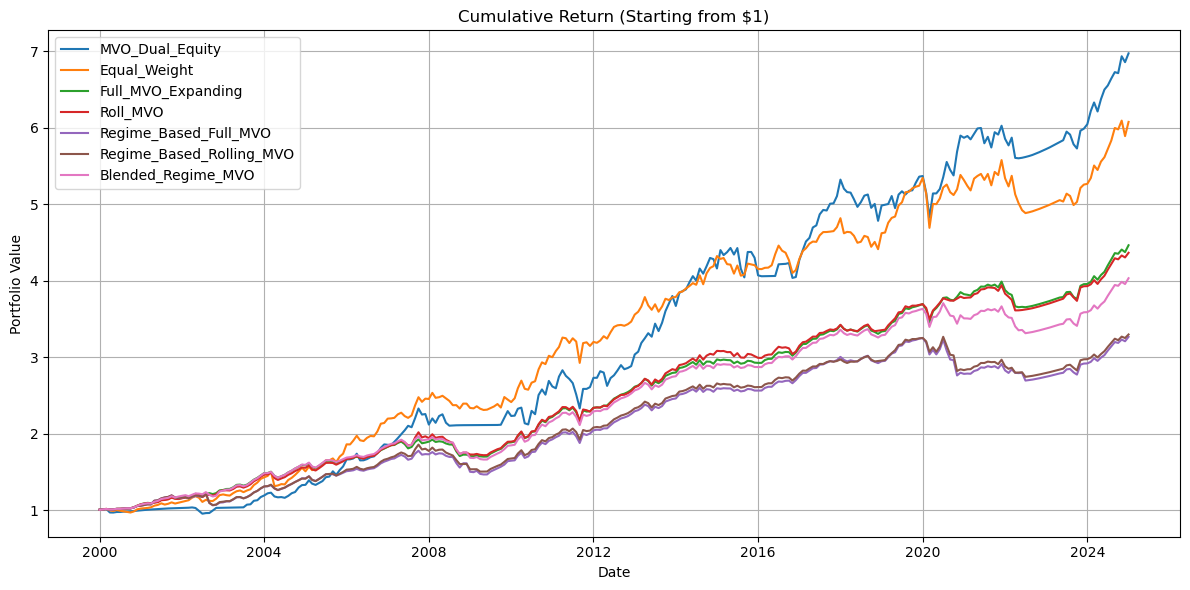

In [17]:
# Compute cumulative returns starting at $1
cumulative_returns = (1 + combined_returns).cumprod()

# Plot
plt.figure(figsize=(12, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Return (Starting from $1)")
plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Peformance Metrics

In [18]:
metrics = {
    col: calc_metrics(combined_returns[col].dropna(), None, df['TB3M_ROR'].loc[combined_returns[col].dropna().index])
    for col in combined_returns.columns
}
metrics_df = pd.DataFrame(metrics).T

metrics_df

,Annual Return,Excess Return,Annual Std,Sharpe,Max Drawdown,% Profit Months
MVO_Dual_Equity,0.085223,0.066196,0.094089,0.703553,-0.176346,0.734219
Equal_Weight,0.078214,0.059301,0.082071,0.722554,-0.124564,0.661130
Full_MVO_Expanding,0.062788,0.044122,0.050179,0.879296,-0.116839,0.707641
Roll_MVO,0.062020,0.043367,0.053436,0.811572,-0.148574,0.704319
Regime_Based_Full_MVO,0.050332,0.031868,0.061742,0.516143,-0.174900,0.691030
Regime_Based_Rolling_MVO,0.050605,0.032136,0.059874,0.536721,-0.190289,0.714286
Blended_Regime_MVO,0.058657,0.040059,0.053215,0.752778,-0.154717,0.697674


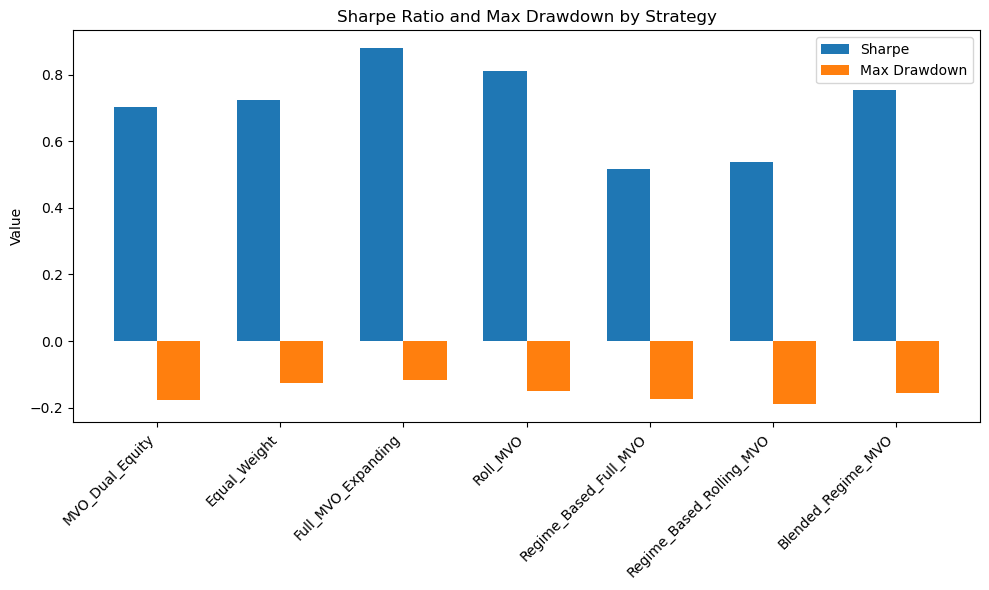

In [20]:
# Sharpe & Max Drawdown

fig, ax = plt.subplots(figsize=(10, 6))
indices = range(len(metrics_df))
bar_width = 0.35

ax.bar([i - bar_width/2 for i in indices], metrics_df['Sharpe'], width=bar_width, label='Sharpe')
ax.bar([i + bar_width/2 for i in indices], metrics_df['Max Drawdown'], width=bar_width, label='Max Drawdown')

ax.set_xticks(indices)
ax.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax.set_ylabel('Value')
ax.set_title('Sharpe Ratio and Max Drawdown by Strategy')
ax.legend()
plt.tight_layout()
plt.show()


Regime Incorporation: Shortcomings
1. Full-Sample Dynamic MVO Wins
- Expanding-window MVO across all data posts the best Sharpe and lowest drawdown.
- Adding smoothing/shrinkage to regime-based rules still falls short of this baseline.
2. Diversification Alone Works
- Equal-weight or MVO on the four Dual_* series smooths returns via low correlations.
- Simple diversification often beats a rigid regime filter.
3. Binary Signal Is Noisy and Late
- The 0/1 VIX threshold misses gradual shifts in volatility.
- By the time it flips "high-vol," the market has usually already moved.
4. Hard On/Off Switching Costs You
- Jumping fully into cash or defensives triggers big trades, slippage, and fees.
- You risk missing quick rebounds, dragging down performance.
5. Smoothing/Shrinkage Only Goes So Far
- Blending or smoothing the binary signal reduces whipsaw but doesn't improve its core timing or accuracy.